# Job Function TFIDF Classification

I'll be analyzing how well a Term Frequency, Inverse Document Frequency (TFIDF) model can classify a record's Job Function using the NLP data found in Job Role and Title.  First I'll create a base line model, then creating a more optimized model using randomsearch, and finally doing an analysis on optimal thresholds for improving performance for each class.

### Why use TFIDF
Because job roles and titles use natural language, the use of TFIDF, a Long-Short-Term Memory (LSTM), or a Transformer neural network model were considered for classification.  While LSTMs and Transformer neural network models can develop more robust, nuanced understandings of texts, such benefits over a TFIDF model are observed when there is a sufficient quantity of NLP data.  Given that the roles and titles in our records contain relatively few terms (having a median length of 3), the benefits of these more sophisticated models are lost but remain more computationally expensive.

Using TFIDF will allow us to cheaply, and efficiently create a model that learns the relationship between significant words in our data and their relationship to job functions.  It will provide us a baseline understanding of how well we'll be able to classify job functions using the available NLP data. 

### Key Findings and Takeaways
- Classification performance is high for 'Academics (Teaching & Learning)'

- Performance may be acceptable for 'Data / Analytics / Research' and 'General Management'

- Performance is poor for all other classes.  However, depending on the acceptable error and in consideration of the similar classes influencing misclassification, use of the model might be acceptable at certain thresholds.

# Setup

In [1]:
# General packages
import pandas as pd
import numpy as np
from scipy.stats import loguniform

import matplotlib.pyplot as plt
import seaborn as sns

import string
import re
import unicodedata
from pathlib import Path

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [2]:
# output path
output_dir = Path("../outputs/visualizations/classification_tfidf")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# specify stopword resources
for resource in [
    "punkt",
    "stopwords",
    "wordnet",
    "averaged_perceptron_tagger"
]:
    nltk.download(resource, quiet=True)

In [4]:
# import data
aff = pd.read_csv("../data/full/cleaned_job_affiliations.csv")

In [5]:
aff.info()

<class 'pandas.DataFrame'>
RangeIndex: 109485 entries, 0 to 109484
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   affiliate_id_18   109485 non-null  str  
 1   function          90572 non-null   str  
 2   title             51280 non-null   str  
 3   role              46778 non-null   str  
 4   management_level  70720 non-null   str  
 5   role_level        29230 non-null   str  
 6   role_imputed      96976 non-null   str  
dtypes: str(7)
memory usage: 5.8 MB


In [6]:
aff.head()

,affiliate_id_18,function,title,role,management_level,role_level,role_imputed
0,a0d3300000CSzeXAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN,Analyst Fellow
1,a0d3300000CSzjSAAT,General Management,NaN,Special Associate to the President,NaN,NaN,Special Associate to the President
2,a0d3300000CSzjUAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN,Analyst Fellow
3,a0d3300000CSzo6AAD,Academics (Teaching & Learning),NaN,Talented and Gifted Teacher,NaN,NaN,Talented and Gifted Teacher
4,a0d3300000CSzo7AAD,Academics (Teaching & Learning),NaN,Elementary Teacher,NaN,NaN,Elementary Teacher


# Filter for Applicable Records
- I've limited the training and analysis to include only records containing both a job Role and Function.  While other categorical variables were considered during EDA, for the time being we'll limit the anlysis to these two columns of our data.  

In [7]:
# filter for eligible records
has_role_mask = aff['role_imputed'].notna() & (aff['role_imputed'] != "")
has_function_mask = aff['function'].notna() & (aff['function'] != "")

func_aff = aff[has_role_mask & has_function_mask]

# Text Preprocessing

In [8]:
# prepearing wordnet lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [9]:
# for cleaning/preping text 
def prep_text(text):
    # lowercase
    text = text.lower()

    # remove non-ASCII, digits, punctuation
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"\d+", "", text)
    text = text.translate(
        str.maketrans(string.punctuation, " " * len(string.punctuation))
    )
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    tokens = word_tokenize(text)

    # POS tagging
    tagged_tokens = pos_tag(tokens)

    # lemmatize with POS awareness
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]

    # remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    return tokens

In [10]:
# create a cleaned title_role column
func_aff['preped_role'] = func_aff['role_imputed'].apply(lambda x: ' '.join(prep_text(x)))

# encode categorical labels
le = LabelEncoder()
function_int = le.fit_transform(func_aff['function'])

In [11]:
# split data (70% train, 30% test)
X = func_aff['preped_role']
y = function_int

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7, 
                                                    random_state=34, 
                                                    stratify=y)

# Model Creation
The TFIDF model will work in conjuction with a logistic regression model to learn the relationship between terms in 'Role' and job 'Function' classes.

- During the TFIDF stage, term weights will be calculated with rarer terms reciving greater weight.

- During the Logistic Regression stage, term weights will be used as input features for training and classification.

- The model learns which words most strongly relate to a subset of the job function classes.

- During testing, the model produces probabilities that a given job role falls in into each of the 16 classes.


In [12]:
# create Tf-IDF pipeline
tfidf_pipe = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2, 
            max_df=0.9
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            random_state=34, 
            C = 5
        )
    )
])

In [13]:
# baseline model
tfidf_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [14]:
# check vocab size
vocab_size = len(tfidf_pipe.named_steps['tfidf'].vocabulary_)
print(f"{vocab_size} words in vocabulary")

12256 words in vocabulary


# Baseline Evaluation
Because job function classes are so imbalanced, we'll be using F1 as the primary performance metric.  A confusion matrix has also been provided for visualization and comparison.
- Baseline F1 scores are above 0.7 for only 2 of 16 classes.

- F1 scores fall below 0.5 for half of the classes

- The confusion matrix highlights how 'General Managment' and 'Program and Product Management' are causing notably more mislabelings than other classes.  This is due to the overlap in language used to describe roles in those classes.

In [15]:
# confusion matrix plot
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    
    plt.savefig(
        output_dir / save_name,
        dpi=300,
        bbox_inches="tight"
        )
    plt.show()
    plt.close()

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      7977
           1       0.48      0.51      0.49      1156
           2       0.66      0.67      0.66      3085
           3       0.57      0.31      0.40       398
           4       0.63      0.55      0.59       878
           5       0.54      0.67      0.60      2570
           6       0.65      0.48      0.55       659
           7       0.78      0.64      0.70       434
           8       0.55      0.56      0.55      1523
           9       0.45      0.45      0.45      1642
          10       0.27      0.16      0.20       580
          11       0.49      0.37      0.42       633
          12       0.47      0.54      0.50      2604
          13       0.58      0.42      0.49      1017
          14       0.34      0.16      0.21       852
          15       0.52      0.43      0.47       602

    accuracy                           0.64     26610
   macro avg       0.55   

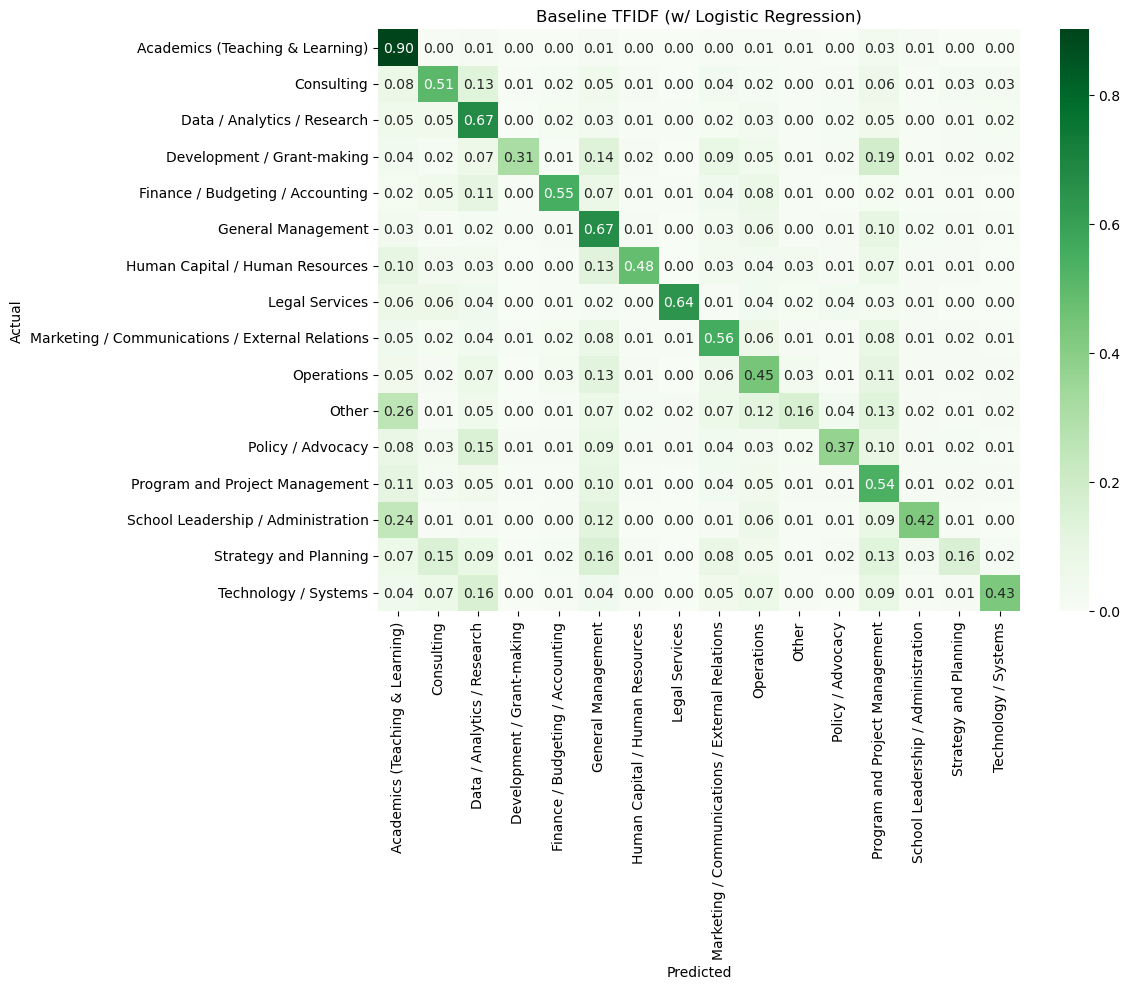

In [16]:
# baseline performance
y_pred_baseline = tfidf_pipe.predict(X_test)
baseline_classes = le.classes_

# precision, recall, support, and f1 score
print(classification_report(y_test, y_pred_baseline))

print(f"Macro F1: {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")

# confusion matrix
plot_confusion_matrix(y_test, 
                      y_pred_baseline, 
                      baseline_classes, 
                      "Baseline TFIDF (w/ Logistic Regression)", 
                      "baseline_tfidf.png")

# Hyperparameter Tuning
I'll be using Random Search to identify more optimal hyperparameters for:
- Term n-gram length
- Min term frequency
- Max term frequency
- Regularization strength
- The use of class weights

In [17]:
# create parameter grid for grid search
param_grid = {
    'tfidf__ngram_range': [(1,2), (1,3), (1,4)],
    'tfidf__min_df' : [1, 5, 10],
    'tfidf__max_df' : [0.75, 0.85, 0.9],
    'clf__C' : loguniform(1e-3, 1e2),
    'clf__class_weight': [None, "balanced"]
}

In [ ]:
# create grid search
opt_tfidf = RandomizedSearchCV(tfidf_pipe, 
                        param_grid, 
                        cv=5, 
                        scoring = ['f1_macro', 'precision_macro', 'recall_macro'], 
                        refit = 'f1_macro', 
                        n_jobs = -2,
                        random_state=34)

opt_tfidf.fit(X_train, y_train)


/opt/homebrew/Caskroom/miniconda/base/envs/venv_folio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/venv_folio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/venv_folio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [ ]:
#  check best parameters
print(opt_tfidf.best_params_)
print(opt_tfidf.best_score_)

{'clf__C': np.float64(5.702130713681402), 'clf__class_weight': None, 'tfidf__max_df': 0.85, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 4)}
0.502635029997106


In [ ]:
opt_results = pd.DataFrame(opt_tfidf.cv_results_)

In [ ]:
# The most useful columns
display(opt_results[[
    'rank_test_f1_macro',
    'params',
    'mean_test_f1_macro',
    'std_test_f1_macro',
    'mean_test_precision_macro',
    'mean_test_recall_macro'
    ]].sort_values('rank_test_f1_macro'))

,rank_test_f1_macro,params,mean_test_f1_macro,std_test_f1_macro,mean_test_precision_macro,mean_test_recall_macro
3,1,"{'clf__C': 5.702130713681402, 'clf__class_weig...",0.502635,0.001625,0.536646,0.483283
5,2,"{'clf__C': 8.89411754960392, 'clf__class_weigh...",0.497217,0.001951,0.527427,0.479707
8,3,"{'clf__C': 38.5777968017597, 'clf__class_weigh...",0.491255,0.005121,0.524440,0.473149
6,4,"{'clf__C': 0.10946042457227853, 'clf__class_we...",0.482429,0.002638,0.474375,0.523836
2,5,"{'clf__C': 0.04985858720910053, 'clf__class_we...",0.477158,0.002818,0.473753,0.515802
1,6,"{'clf__C': 1.460371781020505, 'clf__class_weig...",0.475447,0.002490,0.461713,0.520771
9,7,"{'clf__C': 0.011495562200823333, 'clf__class_w...",0.455438,0.003663,0.464822,0.490531
4,8,"{'clf__C': 23.84750338223857, 'clf__class_weig...",0.452409,0.005022,0.437491,0.496088
7,9,"{'clf__C': 0.046590623196217255, 'clf__class_w...",0.387685,0.004525,0.596268,0.347518
0,10,"{'clf__C': 0.0015588646343463795, 'clf__class_...",0.071549,0.000894,0.168117,0.087240


## Optimal Model Performance
- While optimizing our model's hyperparameters does improve performance, F1 remains low for many classes and we can still see how overlapping classes influence misclassification in our confusion matrix.

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      7977
           1       0.47      0.51      0.49      1156
           2       0.66      0.68      0.67      3085
           3       0.56      0.34      0.42       398
           4       0.62      0.57      0.59       878
           5       0.54      0.65      0.59      2570
           6       0.63      0.48      0.55       659
           7       0.76      0.66      0.71       434
           8       0.56      0.57      0.56      1523
           9       0.46      0.44      0.45      1642
          10       0.31      0.17      0.22       580
          11       0.52      0.37      0.43       633
          12       0.48      0.53      0.50      2604
          13       0.56      0.44      0.49      1017
          14       0.34      0.17      0.23       852
          15       0.49      0.44      0.46       602

    accuracy                           0.64     26610
   macro avg       0.55   

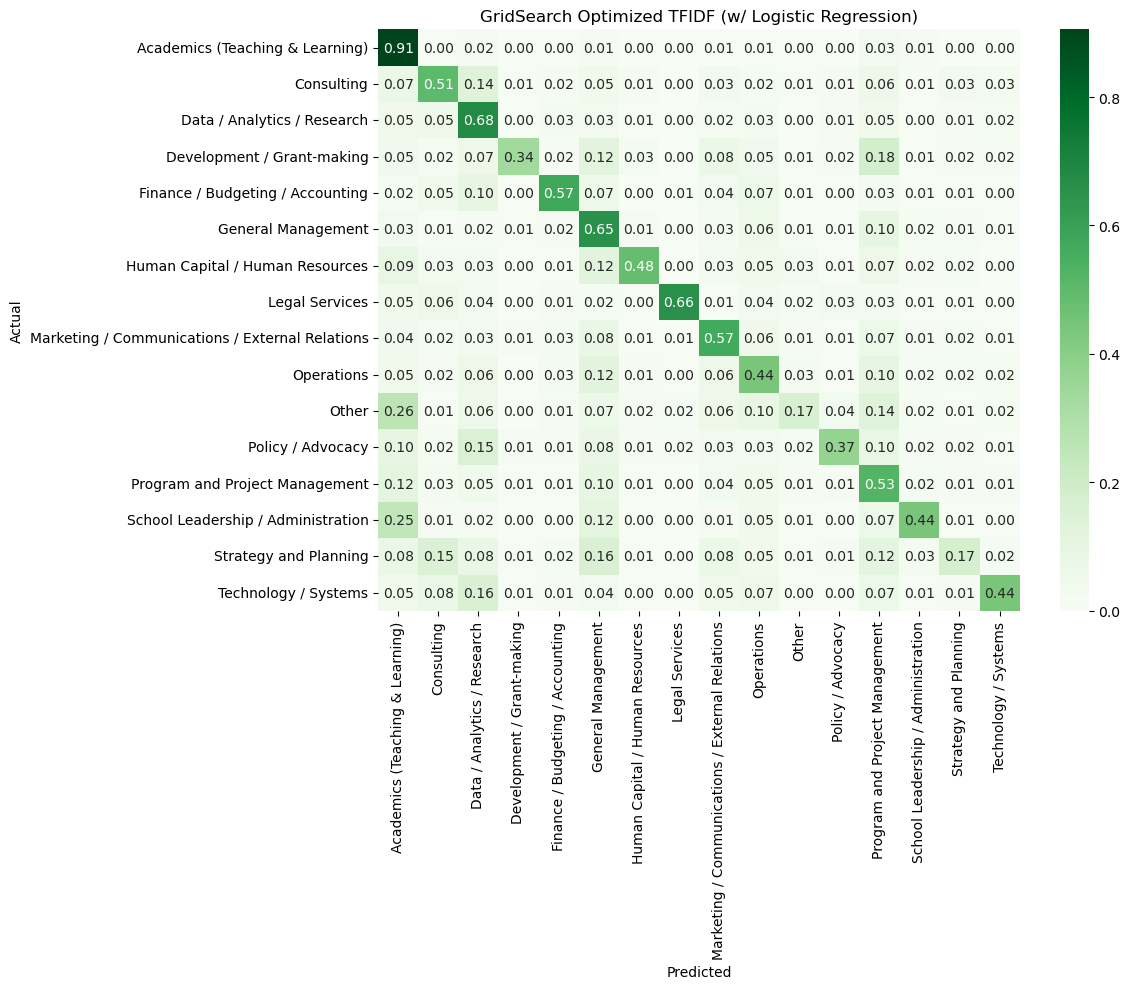

In [ ]:
# grid search best model performance
y_pred_gs = opt_tfidf.predict(X_test)
gs_classes = le.classes_

print(classification_report(y_test, y_pred_gs))
print(f"Macro F1: {f1_score(y_test, y_pred_gs, average='macro'):.4f}")

plot_confusion_matrix(y_test, 
                      y_pred_gs, 
                      gs_classes, 
                      "GridSearch Optimized TFIDF (w/ Logistic Regression)",
                      "optimized_tfidf.png")

## Key Terms
The top 10 key terms and their relative importance in each class are provided below.
- While the overlap between some classes is still likly contributing to poor performance across some classes, the feature importances do help differentiate these classes, provide insight on how respondants classify their job roles, and foreshadow which records will likely be labeled after the classification threshold has been tuned.


In [ ]:
# top  n-grams per class
opt_model = opt_tfidf.best_estimator_

feature_names = opt_model.named_steps["tfidf"].get_feature_names_out()
class_names = le.classes_

terms = 10

feature_importance_data = {}
top_term_list = []

for i, class_name in enumerate(class_names):
    coefs = opt_model.named_steps["clf"].coef_[i]

    top_idx = np.argsort(coefs)[::-1][:terms]

    feature_importance_data[class_name] = pd.DataFrame({
        "term": feature_names[top_idx],
        "importance": coefs[top_idx]
    })

    top_term_list.append(feature_names[top_idx].tolist())

feature_importance_df = pd.concat(
    {k: v.reset_index(drop=True) for k, v in feature_importance_data.items()},
    axis=1
)

display(feature_importance_df)

Academics (Teaching & Learning)                       Consulting             \
                             term importance                  term importance   
0                         teacher  12.207820            consulting   5.602537   
1                       professor  11.152903              advisory   4.950448   
2                      instructor   8.201732               consult   4.720913   
3                        teaching   8.140446            consultant   4.458608   
4                           grade   7.911823    student consultant   4.082528   
5                           teach   7.893352     consultant office   3.811698   
6                            math   7.197112    support consultant   3.635651   
7                         english   6.442307             principle   3.570832   
8                           tutor   6.428394            counsellor   3.427409   
9                         faculty   6.056234  marketing consultant   3.390979   

  Data / Analytics / Research            Development / Grant-making  \
                         term importance                       term   
0                    research  11.087557                development   
1                        data  10.053442                      grant   
2                   analytics   6.931784                       give   
3                  evaluation   5.794005                      donor   
4                      survey   5.078650                advancement   
5                  researcher   4.870586                   prospect   
6                statistician   4.778264        education volunteer   
7                postdoctoral   4.418800          principal teacher   
8                 statistical   4.227579              field manager   
9                     insight   4.223458                  developer   

             Finance / Budgeting / Accounting             ...  \
  importance                             term importance  ...   
0   9.661843                          finance  11.172910  ...   
1   8.588602                        financial   9.408458  ...   
2   6.101596                       accountant   9.212052  ...   
3   5.396508                       accounting   7.922949  ...   
4   5.157425                           budget   7.396380  ...   
5   3.858600                              tax   6.801636  ...   
6   3.621767                       investment   6.693290  ...   
7   3.607362                            audit   5.871950  ...   
8   3.536196                       controller   5.617134  ...   
9   3.497344                           banker   5.597300  ...   

  Policy / Advocacy            Program and Project Management             \
               term importance                           term importance   
0            policy   9.588972                        program   6.887419   
1       legislative   6.348615                        project   4.174138   
2          advocacy   5.615508                    scholarship   4.009726   
3         organizer   4.721210                  intern fellow   3.503980   
4          advocate   4.678136                          youth   3.436787   
5          organize   4.586204             project management   3.358872   
6          attorney   4.360188            teacher coordinator   3.297097   
7             state   4.179449            teacher facilitator   3.269601   
8          outreach   3.822637                           teen   3.206959   
9         canvasser   3.805521                 teacher leader   3.182116   

  School Leadership / Administration            Strategy and Planning  \
                                term importance                  term   
0                     superintendent   9.199098              strategy   
1                            teacher   8.792197             strategic   
2                               dean   8.275621               teacher   
3                             school   7.930502              planning   
4                          principal   5.248

## Classification Threshold Tuneing
Given that F1 is low for many classes, adjusting the classification threshold might allow for partial application of the TFIDF model.  
- The model performance above uses the highest probability labeling.

- Specifying a minimum probability for labeling distict to each class may help reduce some error at the cost of leaving some records unlabeled.

    - These records may be ignored or reviewed manually.

    - Questions to consider: What is the impact of mislabeling?  How much error is acceptable?  

- Below, I've provided visualizations that help frame the tradeoff between raising the threshold for labeling and the proportion of those records that will recieve labeling.  Each visualization also provides the changing F1 scores.

In [ ]:
# best model data
best_pipe = opt_tfidf.best_estimator_
classes = le.classes_
#classes = best_pipe.named_steps["clf"].classes_

# best model probablity and labels
probs = best_pipe.predict_proba(X_test)
max_probs = probs.max(axis=1)
pred_labels = classes[np.argmax(probs, axis=1)]

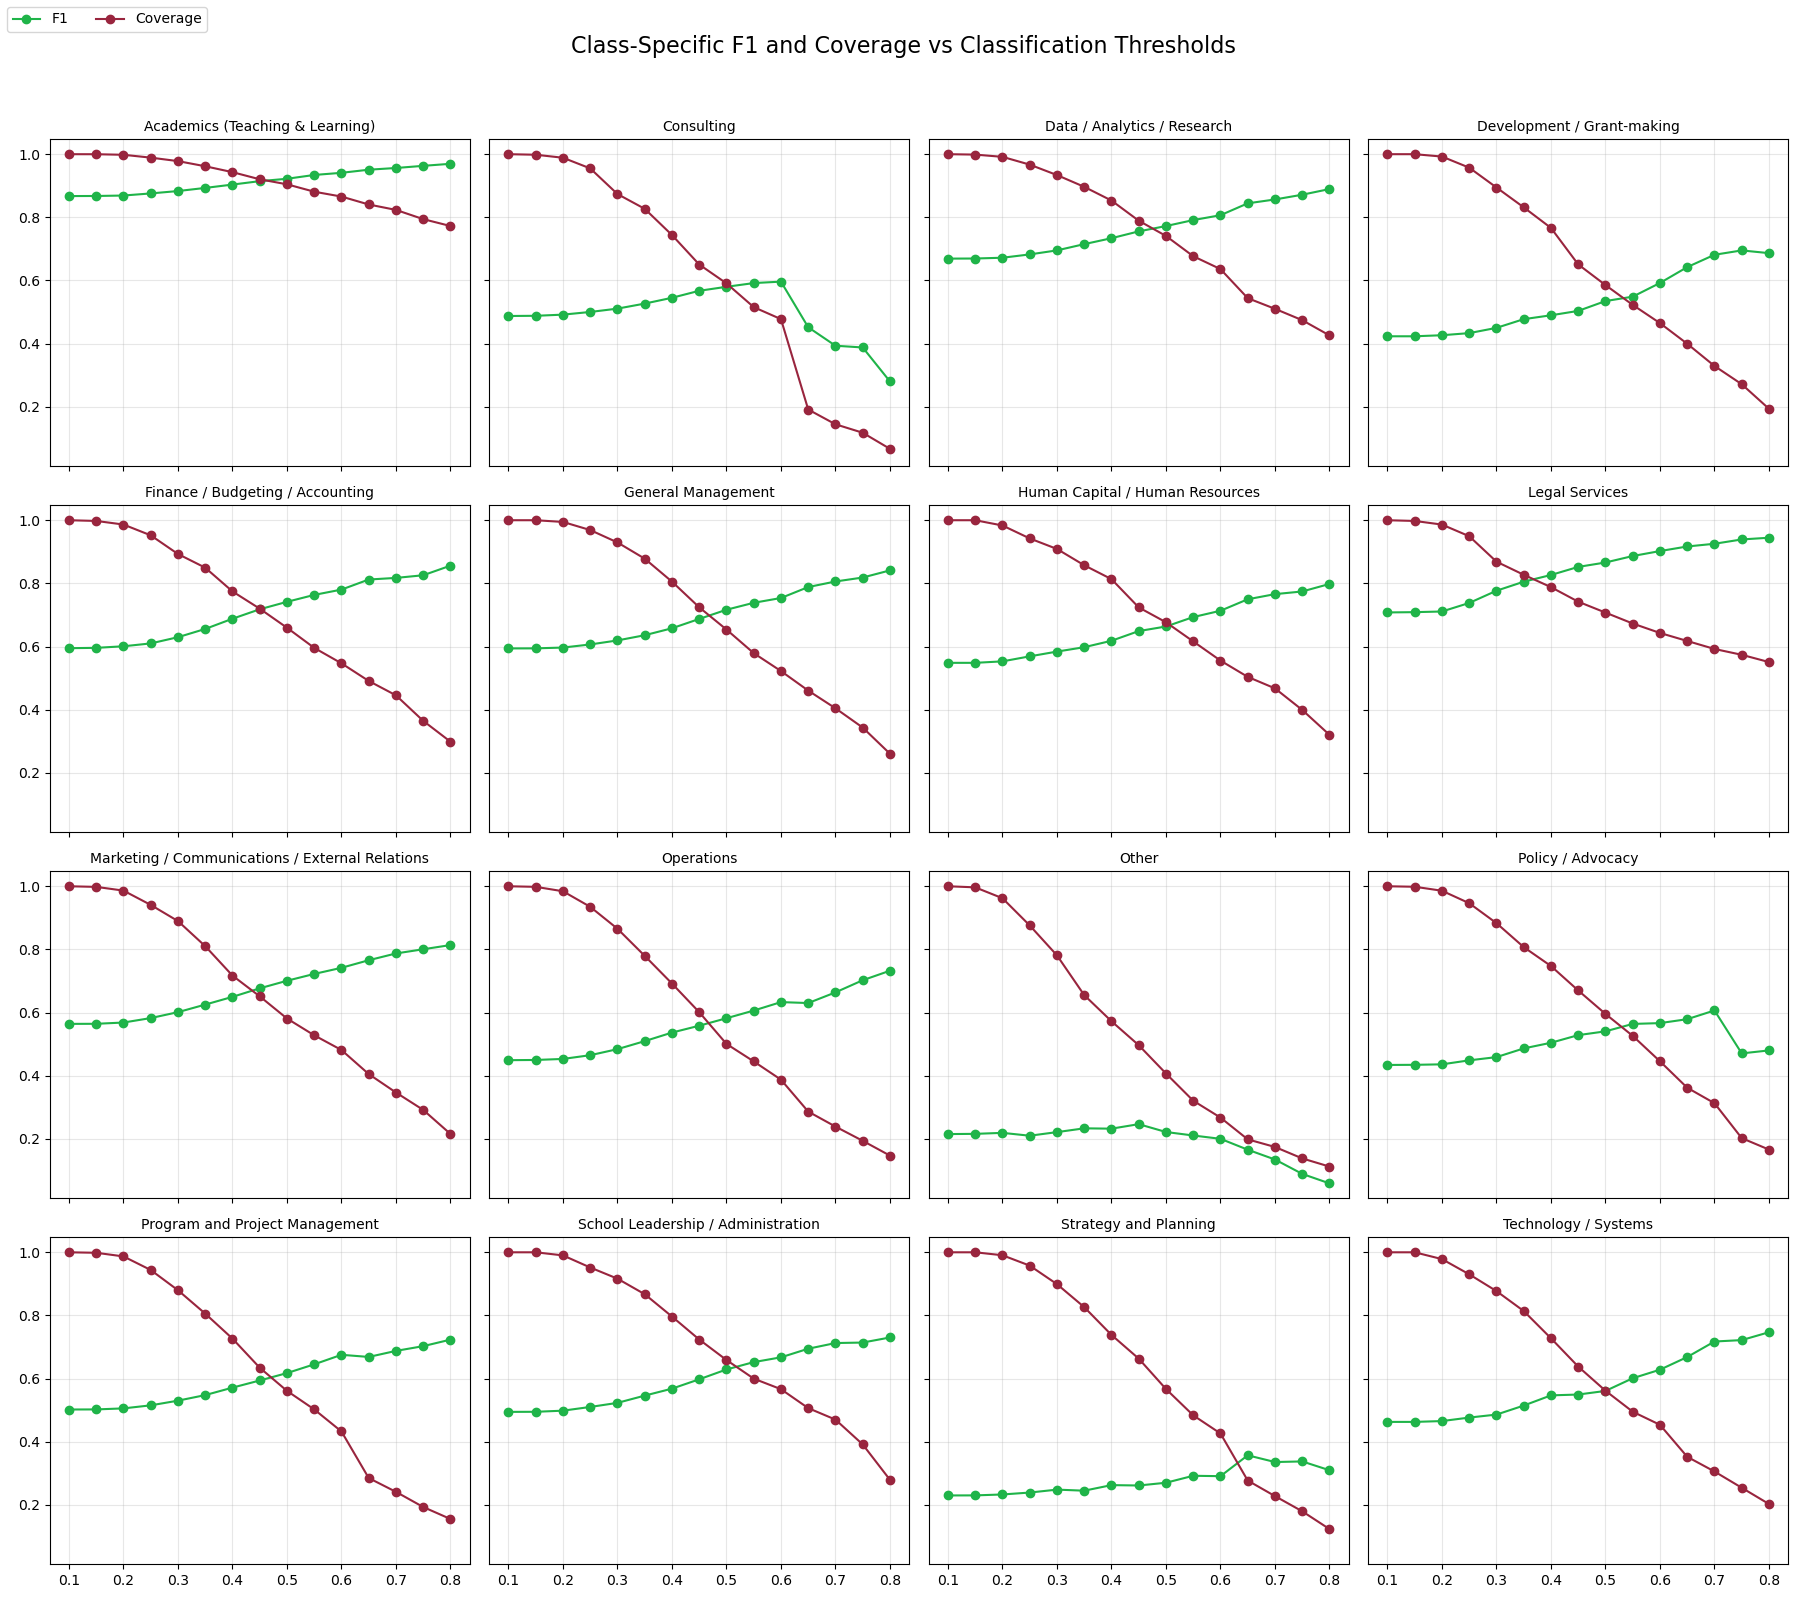

In [ ]:
# testing label thresholds between 0.1 and 0.85 at 0.05 intervals
thresholds = np.arange(0.10, 0.85, 0.05)
#classes = le.classes_

# create a 4x4 figure for 16 classes
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(18, 16),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

# loop through each class and create a distinct threshold vs coverage, F1 score vis
for i, class_name in enumerate(classes):
    ax = axes[i]
    class_code = le.transform([class_name])[0]
    results = []

    for i, class_name in enumerate(classes):
        ax = axes[i]
        class_code = le.transform([class_name])[0]
        results = []

        for t in thresholds:
            class_mask = (np.array(y_test) == class_code)
            
            # filter to only records belonging to this class
            class_probs = max_probs[class_mask]
            class_preds = pred_labels[class_mask]
            class_true = np.array(y_test)[class_mask]
            
            accepted = class_probs >= t

            if accepted.sum() > 0:
                f1 = f1_score(
                    (class_true[accepted] == class_code),
                    (class_preds[accepted] == class_code),
                    zero_division=0
                )
                class_coverage = accepted.mean()
            else:
                f1 = 0
                class_coverage = 0

            results.append({
                "threshold": t,
                "f1": f1,
                "coverage": class_coverage
            })

    # graph f1 score
    ax.plot(
        thresholds,
        [r['f1'] for r in results],
        marker='o',
        color = '#1fb449',
        label='F1'
    )
    # graph coverage
    ax.plot(
        thresholds,
        [r['coverage'] for r in results],
        marker='o',
        color = '#99253E',
        label='Coverage'
    )

    ax.set_title(class_name, fontsize=10)
    ax.grid(alpha=.3)

# one legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()

# design
fig.legend(
    handles,
    labels,
    loc='upper left',
    ncol=2
)

fig.suptitle(
    "Class-Specific F1 and Coverage vs Classification Thresholds",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    output_dir / "class_threshold_f1_coverage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# Final Thoughts

### Analysis Limitations
- Our performance metrics and measures of error don't factor in what might be considered 'close-enough' error.  For example, a job in our testing set might be classified as 'General Management' when it is really 'Operations'.  In practice, such a misclassification might be negligble. Such case-by-case misclassifications would require a more nuanced analysis to quantify.

- The TFIDF model will give greater weight to terms unique to classes.  This is reflected in the top-10-terms and their relative importances.  However, this doesn't necessarily capture the full impact of how words used across job function classes leads to misclassification in the absence of these more significant terms.

### Areas of Future Study
- Investigate how consolidating similar classes may help improve performance.

- Evaluate the usefulness of other variables in the organization's database to create a more sophisticated classification model.

### Recommendations
- Consider a partial application of the model:

    - Tune classification thresholds on per-class basis to reduce misclassification.

    - Exclude classes with performance that fails to pass a minimum threshold at any F1 score (such as 'Strategy and Planning' which never rises above 0.4)
